---
title: Site location problems where certain sites must be included 
image: image.png
execute: 
  enabled: true
---

In [1]:
from lokigi.site import SiteProblem
import pandas as pd

In [2]:
problem = SiteProblem()
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson", candidate_id_col="site")
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )
problem.add_region_geometry_layer("https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

In [ ]:
solutions = problem.solve(p=4, objectives="p_median")
solutions.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[0, 2, 3, 4]",5.08,5.12,7.82,16.69,LSOA L...
1,None,"[2, 3, 4, 5]",5.11,5.05,7.42,16.69,LSOA L...
2,None,"[1, 2, 3, 5]",5.20,5.07,7.75,16.69,LSOA L...
3,None,"[0, 1, 2, 3]",5.22,5.21,8.34,16.69,LSOA L...
4,None,"[0, 2, 3, 5]",5.23,5.19,8.06,16.69,LSOA L...
5,None,"[1, 2, 3, 4]",5.28,5.33,8.32,16.69,LSOA L...
6,None,"[0, 2, 4, 5]",6.05,5.90,9.07,16.69,LSOA L...
7,None,"[0, 1, 2, 5]",6.14,5.92,9.33,16.69,LSOA L...
8,None,"[0, 1, 2, 4]",6.24,6.17,9.69,16.69,LSOA L...
9,None,"[1, 2, 4, 5]",6.33,6.17,9.26,16.69,LSOA L...


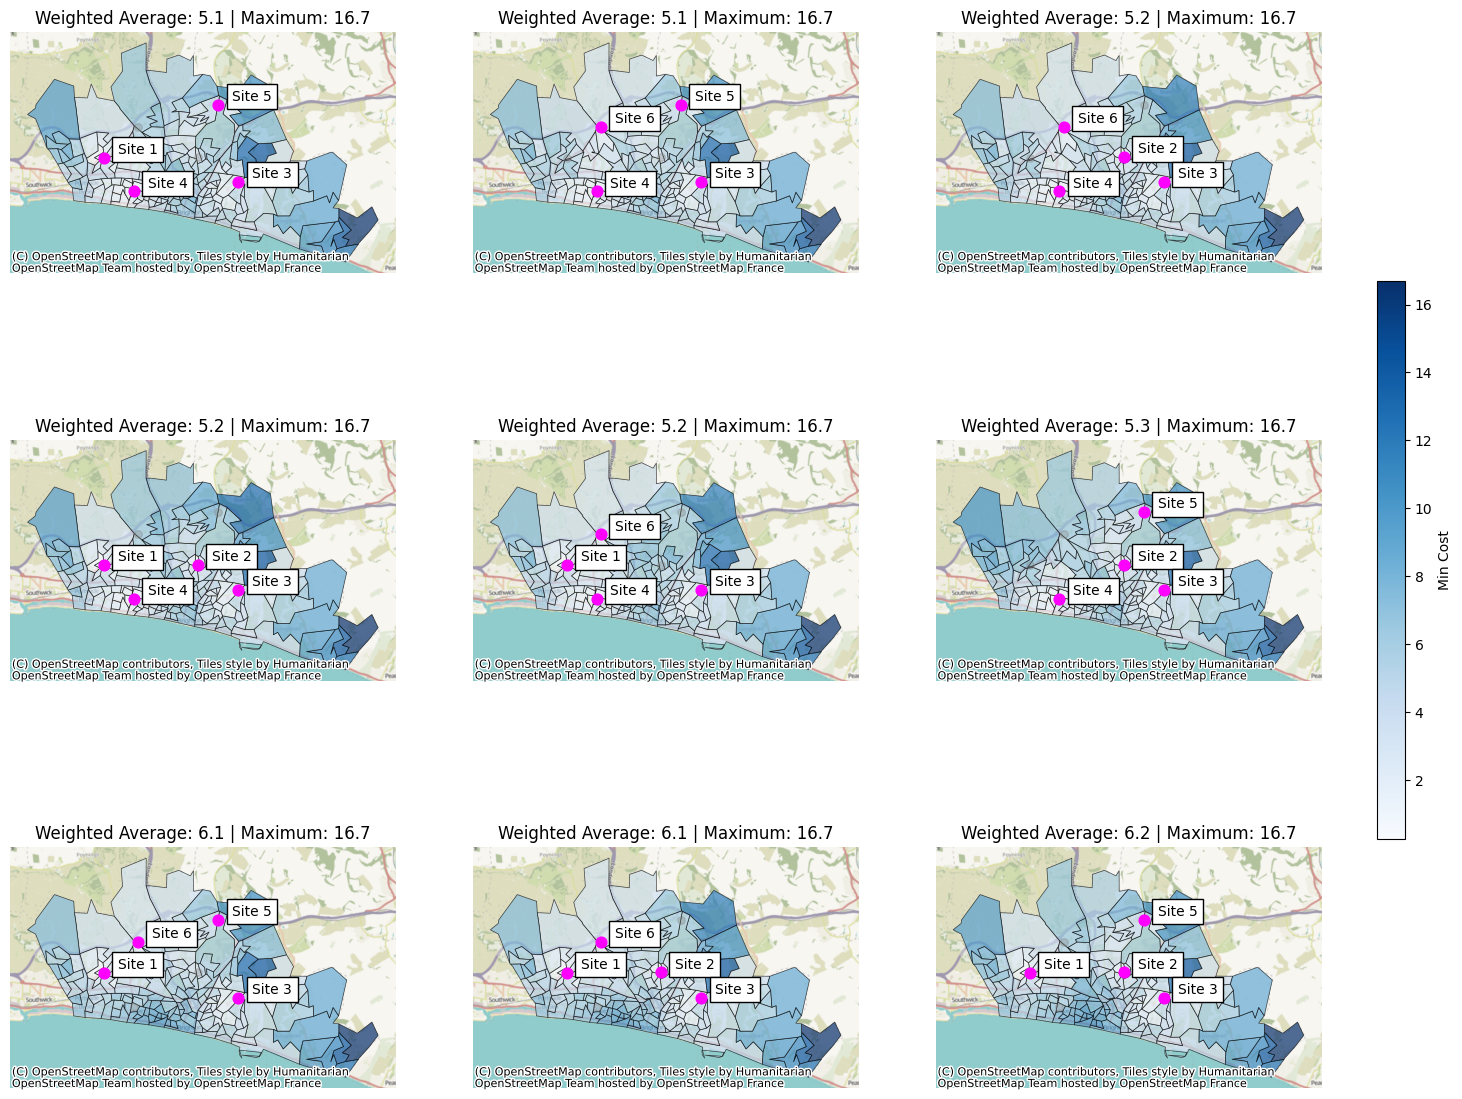

In [4]:
solutions.plot_n_best_combinations(n_best=9, n_cols=3)

However, looking at our sites, we can see there's another column this time that specifies whether the site must be included, and the version of our code above hasn't taken that into account. 

In [5]:
problem.show_sites()

,index,site,existing,geometry
0,0,Site 1,Y,POINT (527142.275 106616.053)
1,1,Site 2,Y,POINT (531493.995 106639.488)
2,2,Site 3,N,POINT (533356.778 105476.782)
3,3,Site 4,N,POINT (528513.424 105052.43)
4,4,Site 5,N,POINT (532421.163 109069.196)
5,5,Site 6,N,POINT (528716.452 108042.794)


So a lot of the solutions provided wouldn't be valid. 

Let's reimport this sites data, but this time passing in a new parameter that lokigi supports - the `required_sites_col` parameter. This will then look for common options in that column that could indicate that a site must be included in the final solution: `"Yes", "yes", "Y", "y", True, true, or 1.`

In [6]:
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson",
                  candidate_id_col="site",
                  required_sites_col="existing")


Now we will solve again. Note that we don't need to specify anything different in our call to `.solve()` - it will automatically look for the required_sites_col if we've passed that in when setting up the problem. 

In [ ]:
solutions = problem.solve(p=4, objectives="p_median")
solutions.show_solutions()

,site_names,site_indices,weighted_average,unweighted_average,90th_percentile,max,problem_df
0,None,"[0, 1, 2, 3]",5.22,5.21,8.34,16.69,LSOA L...
1,None,"[0, 1, 2, 5]",6.14,5.92,9.33,16.69,LSOA L...
2,None,"[0, 1, 2, 4]",6.24,6.17,9.69,16.69,LSOA L...
3,None,"[0, 1, 3, 4]",6.63,6.43,11.32,21.71,LSOA L...
4,None,"[0, 1, 3, 5]",6.83,6.48,11.58,22.86,LSOA L...
5,None,"[0, 1, 4, 5]",7.67,7.27,11.67,21.71,LSOA L...


We can see that this time far fewer possible solutions have been passed back - only those that meet the criteria of having the specified sites included. 

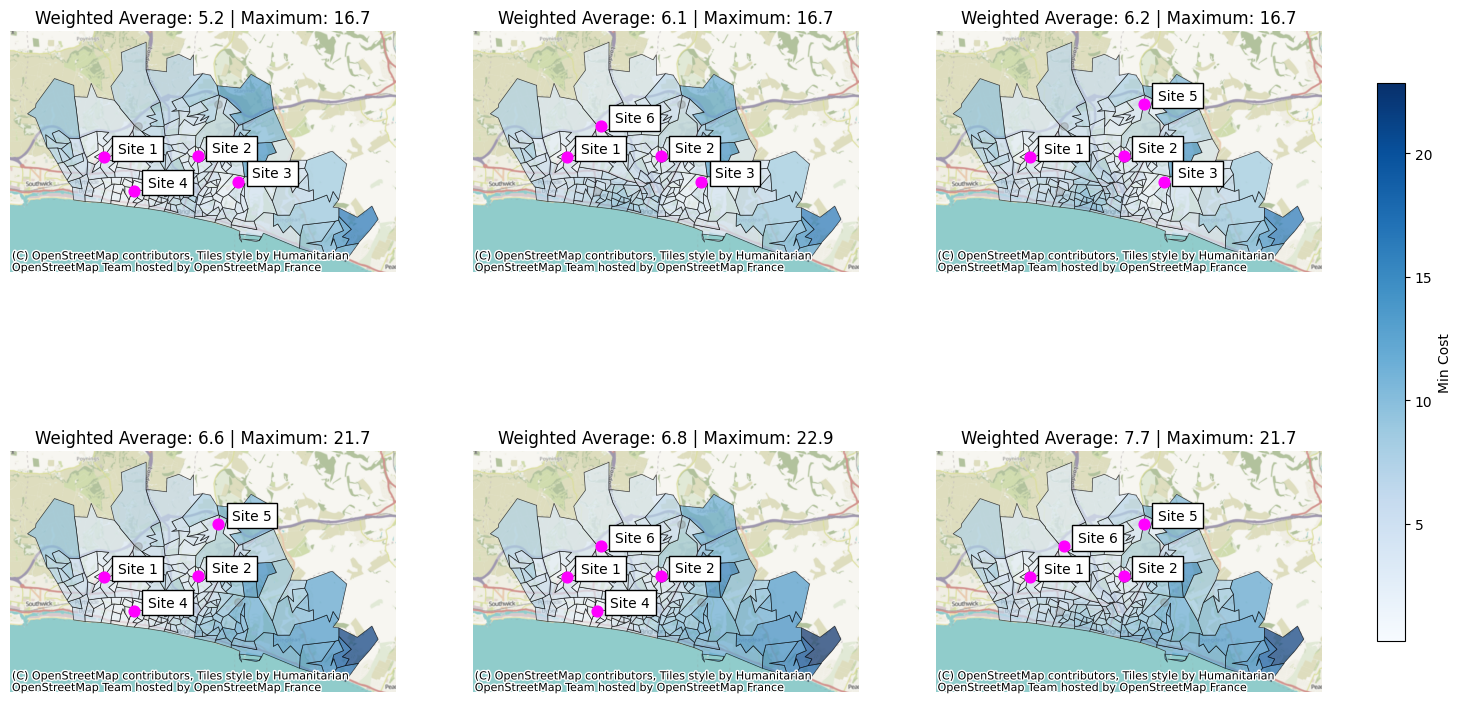

In [8]:
solutions.plot_n_best_combinations(n_cols=3)

Because of the constraints provied, the best solution here (weighted average travel time of 5.2 minutes for sites 1, 2, 3 and 4) is very slightly worse than the unconstrained best solution (weighted average travel time of 5.1 minutes for sites 1, 3, 4 and 5). 

In addition, we can see that the three worst solutions, which don't include site 3, have a worse travel time for the LSOA in the bottom right hand corner, which is contributing to a significantly worse maximum travel time for those solutions. 